# 03 xclip.ipynb — Full Pipeline

Полный pipeline: индексация → поиск → оценка.

Для запуска выполни ячейки сверху вниз.

## 1. Импорты

In [1]:
import sys
sys.path.insert(0, '.')

import torch
torch.cuda.set_device(2)
_ = torch.zeros(1, device='cuda:2')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path

import config
from utils.download import load_annotations
from utils.frames import extract_frames
from utils.clip_embedder import XCLIPEmbedder
from utils.indexing import build_index, save_index, load_index
from utils.search import search_index, group_segments
from utils.metrics import compute_metrics, per_query_stats, iou_with_windows, KS

/home/vadim.akhmetov/work/natural-language-video-search/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Настройка

In [2]:
# ── Модель ────────────────────────────────────────────────────
XCLIP_MODEL_NAME = config.XCLIP_MODEL_NAME   # "microsoft/xclip-base-patch32"
XCLIP_DEVICE     = config.XCLIP_DEVICE        # "cuda:2"

# ── Режим индексации ──────────────────────────────────────────
WINDOW_SIZE = int(config.WINDOW_SIZE_SEC)
WINDOW_STEP = int(config.WINDOW_STEP_SEC)

# ── Поиск ─────────────────────────────────────────────────────
SEARCH_K = config.SEARCH_K

# ── Производные пути (не менять) ──────────────────────────────
INDEX_TYPE = "xclip_window"
INDEX_DIR  = config.INDEX_XCLIP_DIR
GAP_SEC    = config.GAP_WINDOW_SEC

config.RESULTS_DIR.mkdir(parents=True, exist_ok=True)
INDEX_DIR.mkdir(parents=True, exist_ok=True)

print(f"XCLIP_MODEL  : {XCLIP_MODEL_NAME}")
print(f"INDEX_DIR    : {INDEX_DIR}")
print(f"RESULTS_DIR  : {config.RESULTS_DIR}")

XCLIP_MODEL  : microsoft/xclip-base-patch32
INDEX_DIR    : /home/vadim.akhmetov/work/natural-language-video-search/notebooks/data/qvhighlights/index_xclip
RESULTS_DIR  : /home/vadim.akhmetov/work/natural-language-video-search/notebooks/data/qvhighlights/results


## 3. Загрузка моделей

In [3]:
embedder = XCLIPEmbedder(XCLIP_MODEL_NAME, XCLIP_DEVICE)
print(f"XCLIPEmbedder loaded: {XCLIP_MODEL_NAME} on {XCLIP_DEVICE}")

Loading weights: 100%|██████████| 591/591 [00:00<00:00, 5217.78it/s]


XCLIPEmbedder loaded: microsoft/xclip-base-patch32 on cuda:2


## 4. Индексация

Строит FAISS-индекс (window, D=512).
X-CLIP нативно обрабатывает последовательность кадров (ресэмплинг до 8 внутри embedder).

In [4]:
vid_to_split: dict[str, str] = {}
for split in config.SPLITS:
    path = config.ANNOTATIONS_DIR / f"{split}_downloaded.jsonl"
    if path.exists():
        for item in load_annotations(path):
            vid_to_split[item["vid"]] = split

print(f"Known vids: {len(vid_to_split)}")

Known vids: 105


In [5]:
all_vectors: list[np.ndarray] = []
all_meta: list[dict] = []
faiss_id = 0

video_paths = sorted(config.VIDEO_DIR.glob("*.mp4"))
print(f"Videos to index: {len(video_paths)}  |  INDEX_TYPE={INDEX_TYPE}")

BATCH_SIZE = config.XCLIP_BATCH_SIZE

for video_path in tqdm(video_paths, desc="Videos"):
    video_id = video_path.stem
    split = vid_to_split.get(video_id, "unknown")
    frames = extract_frames(video_path, fps=config.SAMPLE_FPS)

    step = WINDOW_STEP
    size = WINDOW_SIZE
    windows: list[tuple[float, float, list]] = []
    for w_start in range(0, len(frames) - size + 1, step):
        window_frames = frames[w_start : w_start + size]
        start_sec = float(w_start)
        end_sec   = float(w_start + size)
        imgs = [img for _, img in window_frames]
        windows.append((start_sec, end_sec, imgs))

    for batch_start in range(0, len(windows), BATCH_SIZE):
        batch = windows[batch_start : batch_start + BATCH_SIZE]
        window_imgs = [imgs for _, _, imgs in batch]
        vecs = embedder.embed_windows(window_imgs)
        for i, (start_sec, end_sec, _) in enumerate(batch):
            ts = (start_sec + end_sec) / 2.0
            all_vectors.append(vecs[i])
            all_meta.append({
                "faiss_id": faiss_id,
                "video_id": video_id,
                "start_sec": start_sec,
                "end_sec":   end_sec,
                "timestamp_sec": ts,
                "split": split,
            })
            faiss_id += 1

print(f"Total vectors: {len(all_vectors)}")

Videos to index: 105  |  INDEX_TYPE=xclip_window


Videos:   0%|          | 0/105 [00:00<?, ?it/s]

Videos: 100%|██████████| 105/105 [03:56<00:00,  2.26s/it]

Total vectors: 7824


In [6]:
vectors  = np.vstack(all_vectors).astype(np.float32)
metadata = pd.DataFrame(all_meta)

index = build_index(vectors)
save_index(index, metadata, INDEX_DIR)

print(f"Index saved to {INDEX_DIR}")
print(f"  index.ntotal : {index.ntotal:,}")
print(f"  metadata shape: {metadata.shape}")
print(metadata.head(3))

Index saved to /home/vadim.akhmetov/work/natural-language-video-search/notebooks/data/qvhighlights/index_xclip
  index.ntotal : 7,824
  metadata shape: (7824, 6)
   faiss_id                video_id  start_sec  end_sec  timestamp_sec  split
0         0  --d84Ars5ng_60.0_210.0        0.0      2.0            1.0  train
1         1  --d84Ars5ng_60.0_210.0        2.0      4.0            3.0  train
2         2  --d84Ars5ng_60.0_210.0        4.0      6.0            5.0  train


## 5. Поиск

Загружает индекс, прогоняет все запросы.

Выход: `data/qvhighlights/results/search_results.parquet`

In [7]:
index, meta = load_index(INDEX_DIR)
print(f"Index loaded: {index.ntotal:,} vectors  [{INDEX_TYPE}]")

annotations = []
for split in config.SPLITS:
    path = config.ANNOTATIONS_DIR / f"{split}_downloaded.jsonl"
    if path.exists():
        annotations.extend(load_annotations(path))
print(f"Queries: {len(annotations)}")

Index loaded: 7,824 vectors  [xclip_window]
Queries: 107


In [8]:
rows = []

for ann in tqdm(annotations, desc="Search"):
    qid        = ann["qid"]
    query      = ann["query"]
    gt_vid     = ann["vid"]
    gt_windows = str(ann["relevant_windows"])

    query_vec = embedder.embed_text([query])  # (1, D)
    hits = search_index(index, meta, query_vec, k=SEARCH_K)
    segs = group_segments(hits, gap_sec=GAP_SEC)

    for rank, (_, seg) in enumerate(segs.iterrows(), start=1):
        rows.append({
            "qid":        qid,
            "query":      query,
            "gt_vid":     gt_vid,
            "gt_windows": gt_windows,
            "index_type": INDEX_TYPE,
            "rank":       rank,
            "pred_vid":   seg["video_id"],
            "pred_start": seg["start_sec"],
            "pred_end":   seg["end_sec"],
            "score":      seg["score"],
        })

results = pd.DataFrame(rows)
print(f"Total rows: {len(results):,}")

out_path = config.RESULTS_DIR / "search_results.parquet"
results.to_parquet(out_path, index=False)
print(f"Saved → {out_path}")

Search: 100%|██████████| 107/107 [00:02<00:00, 35.88it/s]

Total rows: 5,514
Saved → /home/vadim.akhmetov/work/natural-language-video-search/notebooks/data/qvhighlights/results/search_results.parquet


## 6. Оценка

Метрики качества поиска + разбор полётов.

Вход: `search_results.parquet` из секции 5.

In [9]:
if "annotations" not in dir() or len(annotations) == 0:
    annotations = []
    for split in config.SPLITS:
        path = config.ANNOTATIONS_DIR / f"{split}_downloaded.jsonl"
        if path.exists():
            annotations.extend(load_annotations(path))

if "results" not in dir():
    results = pd.read_parquet(config.RESULTS_DIR / "search_results.parquet")

print(f"Results: {len(results):,} rows")
print(f"Queries: {results['qid'].nunique()}")
print(f"Index types: {results['index_type'].unique().tolist()}")

Results: 5,514 rows
Queries: 107
Index types: ['xclip_window']


### Сводная таблица метрик

In [10]:
import seaborn as sns

all_types = results["index_type"].unique().tolist()
metrics_by_type = {}
for idx_type in all_types:
    subset = results[results["index_type"] == idx_type]
    metrics_by_type[idx_type] = compute_metrics(subset, annotations)

summary = pd.DataFrame(metrics_by_type).T
summary.index.name = "index_type"
print(summary.to_string(float_format=lambda x: f"{x:.3f}"))

              video_recall@1  video_recall@2  video_recall@3  video_recall@5  video_recall@10  video_recall@15  video_recall@20  video_precision@1  video_precision@2  video_precision@3  video_precision@5  video_precision@10  video_precision@15  video_precision@20  ndcg@1  ndcg@2  ndcg@3  ndcg@5  ndcg@10  ndcg@15  ndcg@20  video_f1@1  video_f1@2  video_f1@3  video_f1@5  video_f1@10  video_f1@15  video_f1@20  video_mrr  video_map  mean_iou  mean_iou@top1  mean_iou@top5  hit@1@iou03  moment_mrr@iou03  moment_recall@1@iou03  moment_precision@1@iou03  moment_recall@2@iou03  moment_precision@2@iou03  moment_recall@3@iou03  moment_precision@3@iou03  moment_recall@5@iou03  moment_precision@5@iou03  moment_recall@10@iou03  moment_precision@10@iou03  moment_recall@15@iou03  moment_precision@15@iou03  moment_recall@20@iou03  moment_precision@20@iou03  hit@1@iou05  moment_mrr@iou05  moment_recall@1@iou05  moment_precision@1@iou05  moment_recall@2@iou05  moment_precision@2@iou05  moment_recall@3@io

### Heatmap метрик

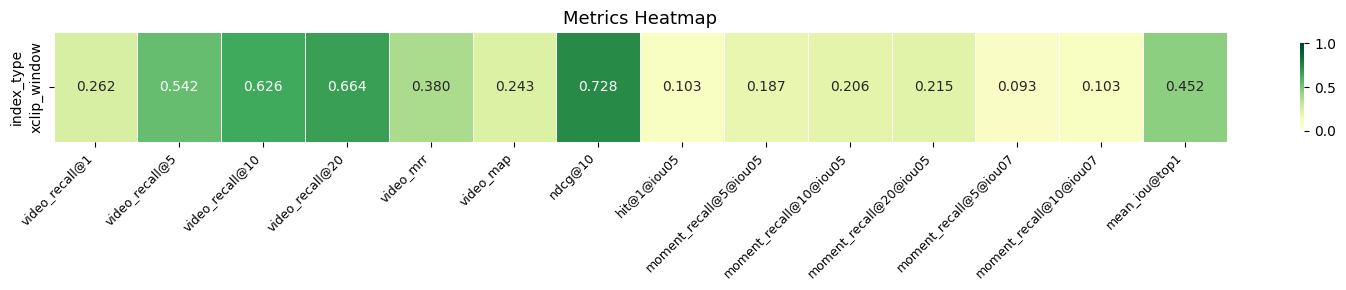

In [11]:
HEATMAP_COLS = [
    "video_recall@1", "video_recall@5", "video_recall@10", "video_recall@20",
    "video_mrr", "video_map", "ndcg@10",
    "hit@1@iou05", "moment_recall@5@iou05", "moment_recall@10@iou05", "moment_recall@20@iou05",
    "moment_recall@5@iou07", "moment_recall@10@iou07",
    "mean_iou@top1",
]
heatmap_cols = [c for c in HEATMAP_COLS if c in summary.columns]
heatmap_df = summary[heatmap_cols]

fig, ax = plt.subplots(figsize=(max(14, len(heatmap_cols) * 1.1), max(3, len(summary) * 0.9)))
sns.heatmap(
    heatmap_df.astype(float), ax=ax, annot=True, fmt=".3f",
    vmin=0, vmax=1, cmap="YlGn", linewidths=0.5, cbar_kws={"shrink": 0.8},
)
ax.set_title("Metrics Heatmap", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
plt.tight_layout()
plt.show()

### Recall@K кривые

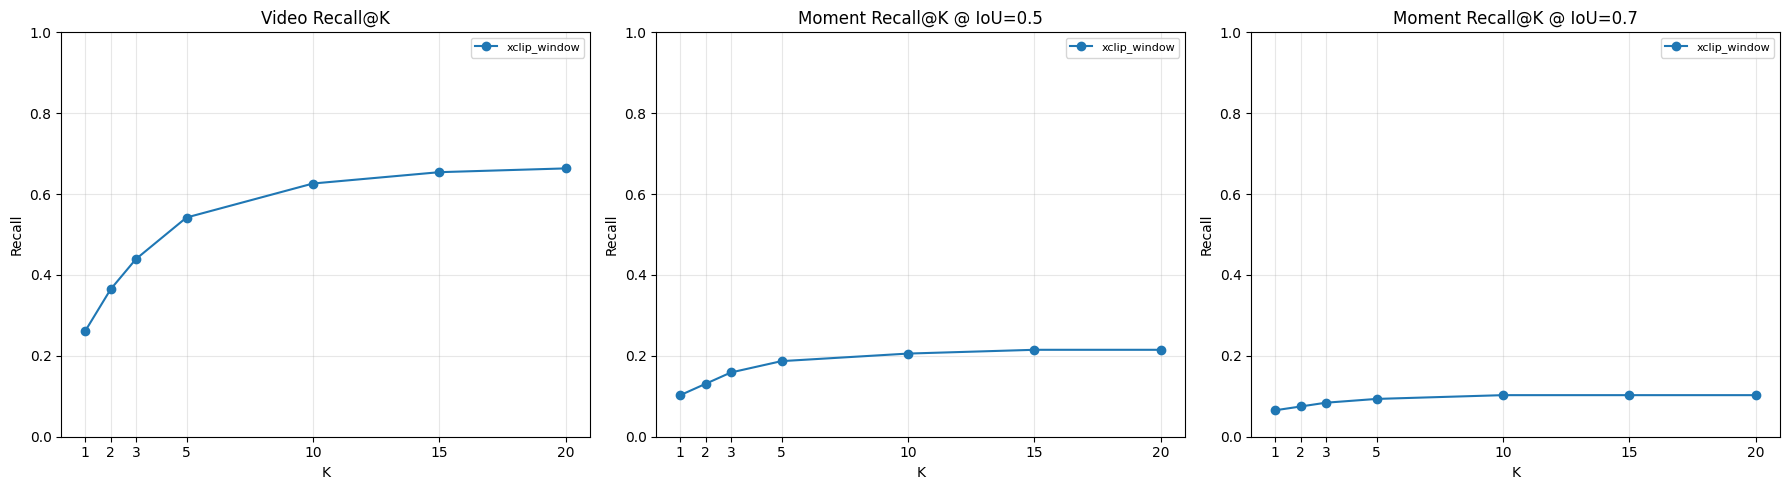

In [12]:
plots_spec = [
    ("Video Recall@K",            [f"video_recall@{k}"        for k in KS]),
    ("Moment Recall@K @ IoU=0.5", [f"moment_recall@{k}@iou05" for k in KS]),
    ("Moment Recall@K @ IoU=0.7", [f"moment_recall@{k}@iou07" for k in KS]),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, cols) in zip(axes, plots_spec):
    for idx_type, row in summary.iterrows():
        vals = [row.get(c, float("nan")) for c in cols]
        ax.plot(KS, vals, marker="o", label=idx_type)
    ax.set_title(title); ax.set_xlabel("K"); ax.set_ylabel("Recall")
    ax.set_ylim(0, 1); ax.set_xticks(KS); ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Video Retrieval

              video_recall@1  video_recall@5  video_recall@10  video_mrr  video_map
index_type                                                                         
xclip_window           0.262           0.542            0.626      0.380      0.243


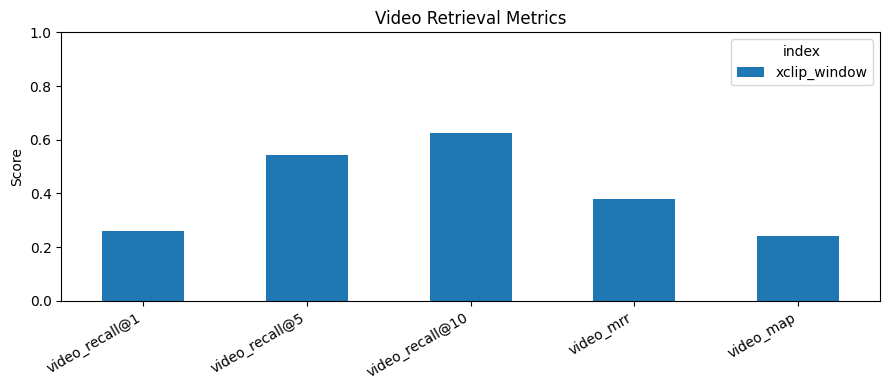

In [13]:
video_cols = ["video_recall@1", "video_recall@5", "video_recall@10", "video_mrr", "video_map"]
video_df = summary[video_cols]
print(video_df.to_string(float_format=lambda x: f"{x:.3f}"))

fig, ax = plt.subplots(figsize=(9, 4))
video_df.T.plot(kind="bar", ax=ax)
ax.set_title("Video Retrieval Metrics"); ax.set_ylabel("Score"); ax.set_ylim(0, 1)
ax.legend(title="index"); plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

### Moment Retrieval

              hit@1@iou03  hit@1@iou05  moment_recall@1@iou05  moment_recall@5@iou05  moment_recall@10@iou05  moment_mrr@iou05  mean_iou
index_type                                                                                                                              
xclip_window        0.159        0.103                  0.103                  0.187                   0.206             0.136     0.334


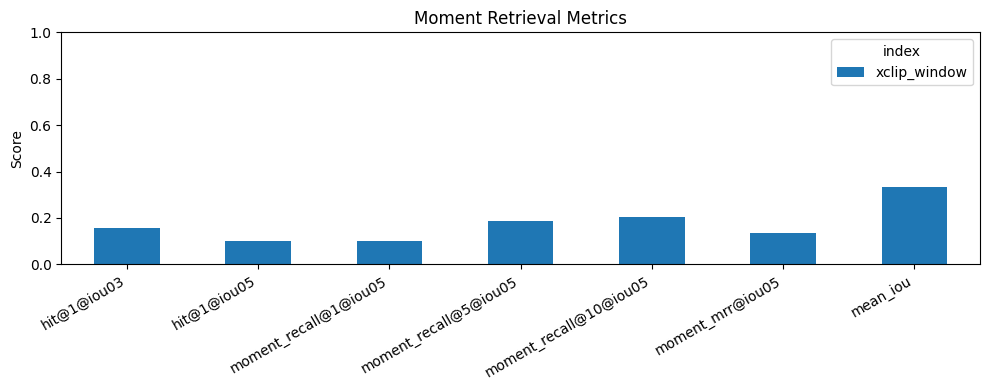

In [14]:
moment_cols = [
    "hit@1@iou03", "hit@1@iou05",
    "moment_recall@1@iou05", "moment_recall@5@iou05", "moment_recall@10@iou05",
    "moment_mrr@iou05", "mean_iou",
]
moment_df = summary[moment_cols]
print(moment_df.to_string(float_format=lambda x: f"{x:.3f}"))

fig, ax = plt.subplots(figsize=(10, 4))
moment_df.T.plot(kind="bar", ax=ax)
ax.set_title("Moment Retrieval Metrics"); ax.set_ylabel("Score"); ax.set_ylim(0, 1)
ax.legend(title="index"); plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

### Разбор полётов

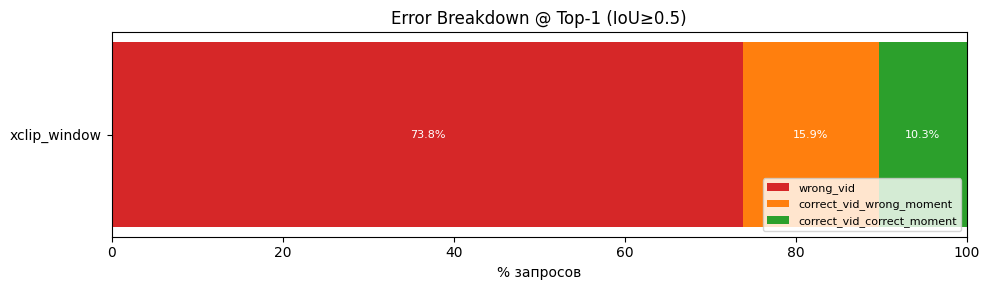


=== XCLIP_WINDOW — Топ-5 лучших ===
                                              query  first_correct_video_rank  best_iou  top1_score
      Muslim woman is organizing clothes into bags.                       1.0  0.357143    0.326371
   Man in baseball cap is riding in a car at night.                       1.0  0.200000    0.274694
Two women are hanging out in a restaurant together.                       1.0  0.666667    0.297452
            Chef peels an onion on a cutting board.                       1.0  0.228571    0.264907
             View as seen from the airplane window.                       1.0  1.000000    0.253581

=== XCLIP_WINDOW — Топ-5 худших (из найденных) ===
                                                                                          query  first_correct_video_rank  best_iou  top1_score
                     a woman showing her outfit to the camera and then her friend does the same                      36.0  0.000000    0.279180
                       

In [15]:
stats = per_query_stats(results, annotations)

_ERROR_COLORS = {
    "wrong_vid":                  "#d62728",
    "correct_vid_wrong_moment":   "#ff7f0e",
    "correct_vid_correct_moment": "#2ca02c",
}
_CATEGORIES = list(_ERROR_COLORS.keys())

error_counts = stats.groupby(["index_type", "error_class"]).size().unstack(fill_value=0)
total_per_type = stats.groupby("index_type").size()
error_pct = error_counts.div(total_per_type, axis=0) * 100
for cat in _CATEGORIES:
    if cat not in error_pct.columns:
        error_pct[cat] = 0.0
error_pct = error_pct[_CATEGORIES]

fig, ax = plt.subplots(figsize=(10, max(3, len(error_pct) * 0.9)))
left = np.zeros(len(error_pct))
for cat in _CATEGORIES:
    vals = error_pct[cat].values
    bars = ax.barh(error_pct.index, vals, left=left, color=_ERROR_COLORS[cat], label=cat)
    for bar, v in zip(bars, vals):
        if v > 3:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
                    f"{v:.1f}%", ha="center", va="center", fontsize=8, color="white")
    left += vals
ax.set_xlabel("% запросов"); ax.set_title("Error Breakdown @ Top-1 (IoU≥0.5)")
ax.legend(loc="lower right", fontsize=8); ax.set_xlim(0, 100)
plt.tight_layout(); plt.show()

cols_show = ["query", "first_correct_video_rank", "best_iou", "top1_score"]
for idx_type in results["index_type"].unique():
    grp = stats[stats["index_type"] == idx_type].sort_values("first_correct_video_rank")
    print(f"\n=== {idx_type.upper()} — Топ-5 лучших ===")
    print(grp.head(5)[cols_show].to_string(index=False))
    finite = grp[grp["first_correct_video_rank"] < float("inf")]
    print(f"\n=== {idx_type.upper()} — Топ-5 худших (из найденных) ===")
    print(finite.tail(5)[cols_show].to_string(index=False))

## 7. ClearML

Логирует эксперимент в ClearML.

In [16]:
os.environ.setdefault("CLEARML_CONFIG_FILE", "clearml.conf")

from utils.clearml_logger import log_experiment

_model_short = XCLIP_MODEL_NAME.split("/")[-1]
task_name = f"{_model_short} / window"

log_experiment(
    task_name=task_name,
    config_dict={
        k: v for k, v in vars(config).items()
        if not k.startswith("_") and not callable(v)
    },
    results_df=results,
    annotations=annotations,
    extra_params={
        "index_type":  INDEX_TYPE,
        "window_size": WINDOW_SIZE,
    },
)
print(f"Logged to ClearML ✓  task_name={task_name!r}")

Logged to ClearML ✓  task_name='xclip-base-patch32 / window'
